### Load core data/ML libs, plotting tools, and sklearn utilities. We also silence warnings for a cleaner read.

In [1]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Library to split data
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

# To build model for prediction
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.preprocessing import LabelEncoder

# To get diferent metric scores
from sklearn.metrics import (f1_score,accuracy_score,recall_score,precision_score,confusion_matrix,)

# To ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

### Read the Excel file and display the head. 

In [2]:
# Chips dataset
chips_path = r"Chips.csv"
df_chips = pd.read_csv(chips_path).drop(columns=['Unnamed: 0'])

def _is_wavenumber(col):
    try:
        float(col)
        return True
    except ValueError:
        return False

meta_cols = [c for c in df_chips.columns if not _is_wavenumber(c)]
spectral_cols = sorted([c for c in df_chips.columns if _is_wavenumber(c)], key=float)
df_chips = df_chips[meta_cols + spectral_cols]
display(df_chips.head())

,Oil Type,Chips Type,500.9077,501.8718,502.8362,503.8003,504.7646,505.7288,506.6931,507.6572,...,2990.558,2991.522,2992.487,2993.451,2994.415,2995.379,2996.344,2997.308,2998.272,2999.236
0,GNO C,GNO C 1,0.348234,0.236003,0.209548,0.259935,0.342311,0.400750,0.265417,-0.057315,...,-1.036244,-0.852184,-0.491486,-0.031239,0.469630,0.888359,1.160025,1.304418,1.295746,1.032411
1,GNO C,GNO C 1,0.578053,0.812538,0.758810,0.585610,0.359928,0.130024,0.097454,0.242493,...,0.467774,0.235349,-0.240331,-0.555291,-0.665669,-0.773821,-0.702902,-0.465736,-0.042730,0.512532
2,GNO C,GNO C 1,-0.905678,0.159808,0.698343,0.792267,0.597913,0.217841,-0.055928,-0.205510,...,-1.746659,-1.791479,-1.547007,-1.371707,-1.322059,-1.321408,-1.265826,-1.183702,-1.038496,-0.751178
3,GNO C,GNO C 1,-0.523754,-0.562153,-0.553895,-0.579130,-0.649199,-0.752685,-0.946942,-1.207011,...,0.037396,-0.115561,-0.209348,-0.420153,-0.636419,-0.790135,-0.742618,-0.500544,-0.039867,0.580814
4,GNO C,GNO C 1,0.741291,0.749648,0.541832,0.263461,-0.060196,-0.403371,-0.680328,-0.867349,...,-1.322968,-1.424861,-1.276221,-0.943091,-0.779689,-0.877925,-0.921020,-0.896654,-0.759721,-0.450661


In [3]:
# Spectral data starts from column 2
spectra = df_chips.iloc[:, 2:]

# Most negative value in the entire spectral dataset
min_value = spectra.min().min()

# Find row and column containing the minimum value
row_idx, col_idx = (spectra == min_value).stack().idxmax()

print("Most negative value:", min_value)
print("Most negative value:", min_value)
print("Row index:", row_idx)
print("Wavenumber:", col_idx)
print("Shift skipped (data is already Z-score normalized; negative values are physically meaningful)")
print("Minimum stays:", df_chips.iloc[:, 2:].min().min())

Most negative value: -4.304114100701882
Most negative value: -4.304114100701882
Row index: 643
Wavenumber: 500.9077
Shift skipped (data is already Z-score normalized; negative values are physically meaningful)
Minimum stays: -4.304114100701882


**Train/test split.** A single stratified 70/30 split is held out up front and reused for every model below (baseline, pre-pruned, post-pruned), so their test-set numbers are directly comparable to each other. `stratify=y` keeps each oil type's proportion the same in both sets; with a few hundred samples split across 5 classes, a plain random split could otherwise leave a class over- or under-represented in the (already small) test set purely by chance.

In [4]:
#Define features (X) and Target (y)
X = df_chips.drop(columns=['Oil Type','Chips Type'])
y= df_chips['Oil Type']
X = X.astype(float)

# Splitting data in train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1, stratify = y)
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (630, 1866)
Shape of test set :  (270, 1866)
Percentage of classes in training set:
Oil Type
SOYO C    0.2
SO C      0.2
GNO C     0.2
VO C      0.2
PO C      0.2
Name: proportion, dtype: float64
Percentage of classes in test set:
Oil Type
PO C      0.2
SOYO C    0.2
GNO C     0.2
VO C      0.2
SO C      0.2
Name: proportion, dtype: float64


**Column-wise (per-wavenumber) z-score normalization, fit on the training split only.**

*Why normalize at all:* each wavenumber column is a distinct Raman-active vibrational mode with its own intrinsic scattering cross-section; cross-sections differ by orders of magnitude between modes for physical reasons unrelated to how well a wavenumber discriminates between oils (e.g. C-H stretching, ~2850-2950 cm⁻¹, is characteristically far more Raman-intense than many fingerprint-region skeletal modes below 1500 cm⁻¹). Column-wise z-scoring ("autoscaling") puts every vibrational mode on equal statistical footing - the same reasoning that makes the K-Means/t-SNE distances in the companion clustering notebooks meaningful.

*Why do this for a Decision Tree, which doesn't need it:* a Decision Tree's splits are threshold cuts on one feature at a time; any per-feature affine rescaling (which z-scoring is) preserves each feature's sample rank order, so it cannot change which side of a split any sample falls on. Accuracy, confusion matrices, and feature-importance *ranking* are mathematically guaranteed identical whether or not this cell runs (verified in this project's `tests/test_scaling_invariance.py`). It is applied anyway so this dataset (already Z-score normalized upstream - see the markdown cell above) and the two NNLS-subtracted chip datasets (which arrive unnormalized) are treated identically, and every reported split threshold below is expressed in the same, comparable unit across all four Decision Tree notebooks.

*Why column-wise, not row-wise (per-spectrum):* row-wise normalization (e.g. Standard Normal Variate) corrects a different problem - multiplicative drift between acquisitions (laser power, exposure, sample positioning) - by rescaling each spectrum to its own mean/std; that is not attempted anywhere in this project.

*Why fit on `X_train` only:* standard practice for any train/test-based transform, so the held-out test set's distribution never influences the transform applied to training data. For a Decision Tree this leakage would in fact be harmless (see above), but there's no reason to rely on that when fitting on train only costs nothing.

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Training features standardized (fit on X_train only).")
print("Training set - max |per-column mean| (should be ~0):", X_train.mean(axis=0).abs().max())
print("Training set - mean per-column std (should be ~1):", X_train.std(axis=0, ddof=0).mean())

Training features standardized (fit on X_train only).
Training set - max |per-column mean| (should be ~0): 5.639228061588096e-17
Training set - mean per-column std (should be ~1): 1.0


### Define a helper function to compute Accuracy/Recall/Precision/F1 (weighted) for any classifier.

In [6]:
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    # predicting using the independent variables
    pred = model.predict(predictors)
    acc = accuracy_score(target, pred)
    recall = recall_score(target, pred, average="weighted")
    precision = precision_score(target, pred, average="weighted")
    f1 = f1_score(target, pred, average="weighted")

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Accuracy": acc,"Recall": recall,"Precision": precision,"F1": f1,},index=[0],)
    return df_perf

### Utility: Confusion matrix to plot a heatmap of the confusion matrix with per-cell percentage annotation.

In [7]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    # 5 oil classes -> a 5x5 confusion matrix
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(5, 5)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

### Baseline Decision Tree (sklearn defaults): Fit a default tree as a baseline for later comparison.

In [8]:
# No class_weight here (unlike the pre-/post-pruned models below): this
# unconstrained baseline exists purely as an overfitting reference point.
model0 = DecisionTreeClassifier(class_weight="balanced",random_state=1)
model0.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [9]:
le = LabelEncoder()

y_encoded = le.fit_transform(y)

print(le.classes_)

['GNO C' 'PO C' 'SO C' 'SOYO C' 'VO C']


In [10]:
for i, name in enumerate(le.classes_):
    print(i, "->", name)

0 -> GNO C
1 -> PO C
2 -> SO C
3 -> SOYO C
4 -> VO C


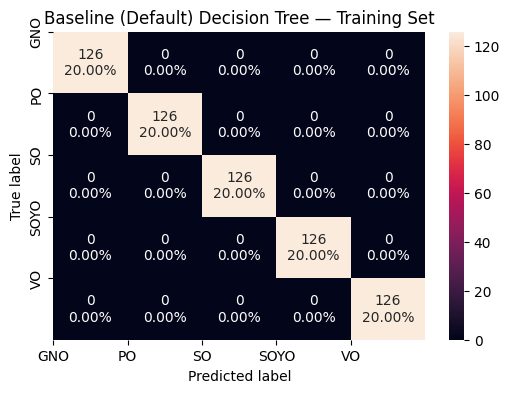

In [11]:
# Draw confusion matrix
confusion_matrix_sklearn(model0, X_train, y_train)

# Get the confusion matrix axes
ax = plt.gca()

# Replace numeric labels with oil names
labels = ['GNO', 'PO', 'SO', 'SOYO', 'VO']

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_title("Baseline (Default) Decision Tree — Training Set")
plt.savefig(r"Images\Chips\confusion_matrix_train_Chips.jpg",dpi=300,bbox_inches="tight")
plt.show()

In [12]:
decision_tree_default_perf_train = model_performance_classification_sklearn(
    model0, X_train, y_train
)
decision_tree_default_perf_train

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


In [13]:
# ============================================================
# Hyperparameters used for the Default Decision Tree
# ============================================================

print("=" * 70)
print("DEFAULT DECISION TREE: ALL HYPERPARAMETERS")
print("=" * 70)

default_params = model0.get_params(deep=True)

for param, value in default_params.items():
    print(f"{param}: {value}")

print("=" * 70)
print("Tree characteristics after fitting")
print("=" * 70)

print(f"Tree depth       : {model0.get_depth()}")
print(f"Number of leaves : {model0.get_n_leaves()}")
print(f"Number of nodes  : {model0.tree_.node_count}")

DEFAULT DECISION TREE: ALL HYPERPARAMETERS
ccp_alpha: 0.0
class_weight: balanced
criterion: gini
max_depth: None
max_features: None
max_leaf_nodes: None
min_impurity_decrease: 0.0
min_samples_leaf: 1
min_samples_split: 2
min_weight_fraction_leaf: 0.0
monotonic_cst: None
random_state: 1
splitter: best
Tree characteristics after fitting
Tree depth       : 11
Number of leaves : 79
Number of nodes  : 157


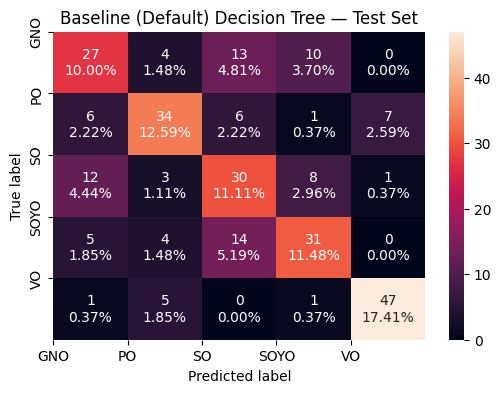

In [14]:
confusion_matrix_sklearn(model0, X_test, y_test)
ax = plt.gca()
labels = ['GNO', 'PO', 'SO', 'SOYO', 'VO']
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_title("Baseline (Default) Decision Tree — Test Set")
plt.savefig(r"Images\Chips\confusion_matrix_Default_test_chips.jpg",dpi=300,bbox_inches="tight")
plt.show()

In [15]:
# ============================================================
# Hyperparameters used for the Default Decision Tree
# ============================================================

print("=" * 70)
print("DEFAULT DECISION TREE: ALL HYPERPARAMETERS")
print("=" * 70)

default_params = model0.get_params(deep=True)

for param, value in default_params.items():
    print(f"{param}: {value}")

print("=" * 70)
print("Tree characteristics after fitting")
print("=" * 70)

print(f"Tree depth       : {model0.get_depth()}")
print(f"Number of leaves : {model0.get_n_leaves()}")
print(f"Number of nodes  : {model0.tree_.node_count}")

DEFAULT DECISION TREE: ALL HYPERPARAMETERS
ccp_alpha: 0.0
class_weight: balanced
criterion: gini
max_depth: None
max_features: None
max_leaf_nodes: None
min_impurity_decrease: 0.0
min_samples_leaf: 1
min_samples_split: 2
min_weight_fraction_leaf: 0.0
monotonic_cst: None
random_state: 1
splitter: best
Tree characteristics after fitting
Tree depth       : 11
Number of leaves : 79
Number of nodes  : 157


In [16]:
decision_tree_default_perf_test = model_performance_classification_sklearn(
    model0, X_test, y_test
)
decision_tree_default_perf_test

,Accuracy,Recall,Precision,F1
0,0.625926,0.625926,0.629598,0.626763


In [17]:
sample_rows = X_test.iloc[:3]
# Predict using model0
pred = model0.predict(sample_rows)

# Show results
for i in range(3):
        print(f"---test case {i+1} ---")
        print("Input Features")
        print(sample_rows.iloc[i])
        print("True Label:", y_test.iloc[i])
        print("Predicted Label:", pred[i])
        print()

---test case 1 ---


Input Features
500.9077    0.874211
501.8718    1.100549
502.8362    1.217131
503.8003    1.335338
504.7646    1.445447
              ...   
2995.379    0.357934
2996.344    1.067009
2997.308    1.634466
2998.272    1.991822
2999.236    1.908753
Name: 255, Length: 1866, dtype: float64
True Label: PO C
Predicted Label: PO C

---test case 2 ---
Input Features
500.9077    1.602391
501.8718    1.336133
502.8362    1.002495
503.8003    0.789421
504.7646    0.673137
              ...   
2995.379    0.050990
2996.344   -0.188395
2997.308   -0.328889
2998.272   -0.330990
2999.236   -0.156241
Name: 570, Length: 1866, dtype: float64
True Label: SOYO C
Predicted Label: PO C

---test case 3 ---
Input Features
500.9077    0.718326
501.8718    0.861732
502.8362    0.890774
503.8003    0.922234
504.7646    0.970694
              ...   
2995.379   -0.962792
2996.344   -0.584138
2997.308   -0.125324
2998.272    0.427304
2999.236    0.965086
Name: 71, Length: 1866, dtype: float64
True Label: GNO C
Pred

### Prepruning

### Pre‑pruning: small grid search: Search over `max_depth`, `max_leaf_nodes`, `min_samples_split`; keep the model with the **best test recall** and smallest train–test gap.

**Pre-pruning hyperparameters.** `max_depth` caps how many splits deep the tree can grow, `max_leaf_nodes` caps the total number of terminal nodes, and `min_samples_split` requires a node to hold at least that many training samples before it is allowed to split further - all three restrict tree growth *during* fitting, as opposed to the cost-complexity post-pruning further below, which grows a full tree first and prunes it back afterward. `class_weight="balanced"` reweights each training sample by `n_samples / (n_classes * n_samples_of_its_class)`, so a rarer class counts for more in the split criterion; it is applied here (and in post-pruning) for robustness to any class imbalance the train/test split introduces. Hyperparameters are chosen by 5-fold cross-validated weighted recall on the training set only - the test set is not touched until the winning model is evaluated once, at the end.

In [18]:
# Define the parameters of the tree to iterate over
max_depth_values = np.arange(2, 7, 2)
max_leaf_nodes_values = [50, 75, 150, 250]
min_samples_split_values = [10, 30, 50, 70]
cv = 5
verbose = 1
param_grid = {
"max_depth": list(max_depth_values),
"max_leaf_nodes": list(max_leaf_nodes_values),
"min_samples_split": list(min_samples_split_values),
}
search = GridSearchCV(
DecisionTreeClassifier(class_weight="balanced", random_state=1),
param_grid=param_grid,
scoring="recall_weighted",cv= StratifiedKFold(n_splits=cv, shuffle=True, random_state= 1),refit=True,
verbose=verbose)
search.fit(X_train, y_train)

columns = ["params", "mean_test_score", "std_test_score", "rank_test_score"]
cv_results = (pd.DataFrame(search.cv_results_)[columns].sort_values("rank_test_score").reset_index(drop=True)
)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


In [19]:
cv_results.head()

,params,mean_test_score,std_test_score,rank_test_score
0,"{'max_depth': 6, 'max_leaf_nodes': 150, 'min_s...",0.620635,0.042710,1
1,"{'max_depth': 6, 'max_leaf_nodes': 250, 'min_s...",0.620635,0.042710,1
2,"{'max_depth': 6, 'max_leaf_nodes': 75, 'min_sa...",0.620635,0.042710,1
3,"{'max_depth': 6, 'max_leaf_nodes': 50, 'min_sa...",0.620635,0.042710,1
4,"{'max_depth': 6, 'max_leaf_nodes': 50, 'min_sa...",0.615873,0.043062,5


In [20]:
search.best_estimator_

,criterion,'gini'
,splitter,'best'
,max_depth,np.int64(6)
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,50
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [21]:
# creating an instance of the best model
model1 = search.best_estimator_

# fitting the best model to the training data
pred = model1.predict(X_train)

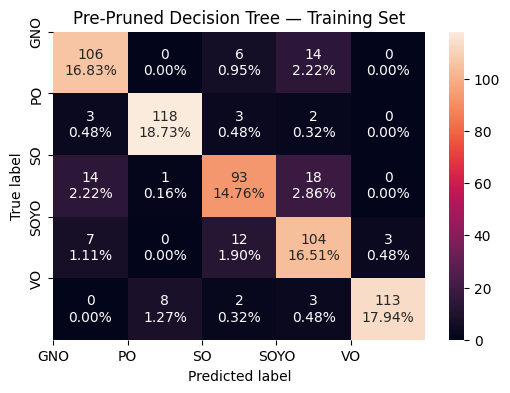

In [22]:
confusion_matrix_sklearn(model1, X_train, y_train)
ax = plt.gca()
labels = ['GNO', 'PO', 'SO', 'SOYO', 'VO']
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_title("Pre-Pruned Decision Tree — Training Set")
plt.savefig(r"Images\Chips\confusion_matrix_train_prepruned_chips.jpg",dpi=300,bbox_inches="tight")
plt.show()

### Visualize the pre‑pruned tree: Plot the structure—useful to see which features split early.

In [23]:
decision_tree_tune_perf_train = model_performance_classification_sklearn(model1, X_train, y_train)
decision_tree_tune_perf_train

,Accuracy,Recall,Precision,F1
0,0.847619,0.847619,0.851594,0.848487


In [24]:
# ============================================================
# Hyperparameters used for the Pre-Pruned Decision Tree
# ============================================================

print("=" * 70)
print("PRE-PRUNED DECISION TREE: ALL HYPERPARAMETERS")
print("=" * 70)

prepruned_params = model1.get_params(deep=True)

for param, value in prepruned_params.items():
    print(f"{param}: {value}")

print("=" * 70)
print("BEST PARAMETERS SELECTED BY GRID SEARCH")
print("=" * 70)

for param, value in search.best_params_.items():
    print(f"{param}: {value}")

print("=" * 70)
print("BEST CROSS-VALIDATION SCORE")
print("=" * 70)

print(f"Best weighted recall: {search.best_score_:.6f}")

print("=" * 70)
print("Tree characteristics after fitting")
print("=" * 70)

print(f"Tree depth       : {model1.get_depth()}")
print(f"Number of leaves : {model1.get_n_leaves()}")
print(f"Number of nodes  : {model1.tree_.node_count}")

PRE-PRUNED DECISION TREE: ALL HYPERPARAMETERS
ccp_alpha: 0.0
class_weight: balanced
criterion: gini
max_depth: 6
max_features: None
max_leaf_nodes: 50
min_impurity_decrease: 0.0
min_samples_leaf: 1
min_samples_split: 10
min_weight_fraction_leaf: 0.0
monotonic_cst: None
random_state: 1
splitter: best
BEST PARAMETERS SELECTED BY GRID SEARCH
max_depth: 6
max_leaf_nodes: 50
min_samples_split: 10
BEST CROSS-VALIDATION SCORE
Best weighted recall: 0.620635
Tree characteristics after fitting
Tree depth       : 6
Number of leaves : 30
Number of nodes  : 59


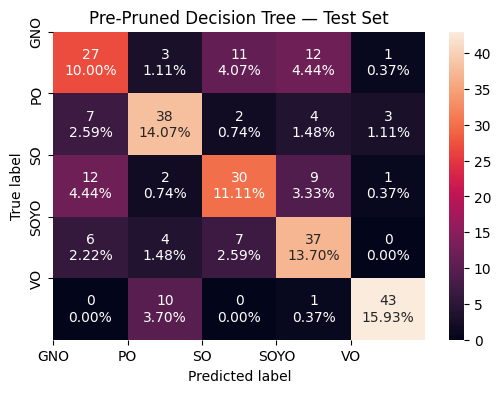

In [25]:
confusion_matrix_sklearn(model1, X_test, y_test)
ax = plt.gca()
labels = ['GNO', 'PO', 'SO', 'SOYO', 'VO']
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_title("Pre-Pruned Decision Tree — Test Set")
plt.savefig(r"Images\Chips\confusion_matrix_test_prepruned_chips.jpg",dpi=300,bbox_inches="tight")
plt.show()

In [26]:
decision_tree_tune_perf_test = model_performance_classification_sklearn(
    model1, X_test, y_test
)
decision_tree_tune_perf_test

,Accuracy,Recall,Precision,F1
0,0.648148,0.648148,0.653806,0.649332


### Save indices/importances for later reuse

In [27]:
feature_names = list(X_train.columns)
importances = model1.feature_importances_
indices = np.argsort(importances)

### Plot the tree

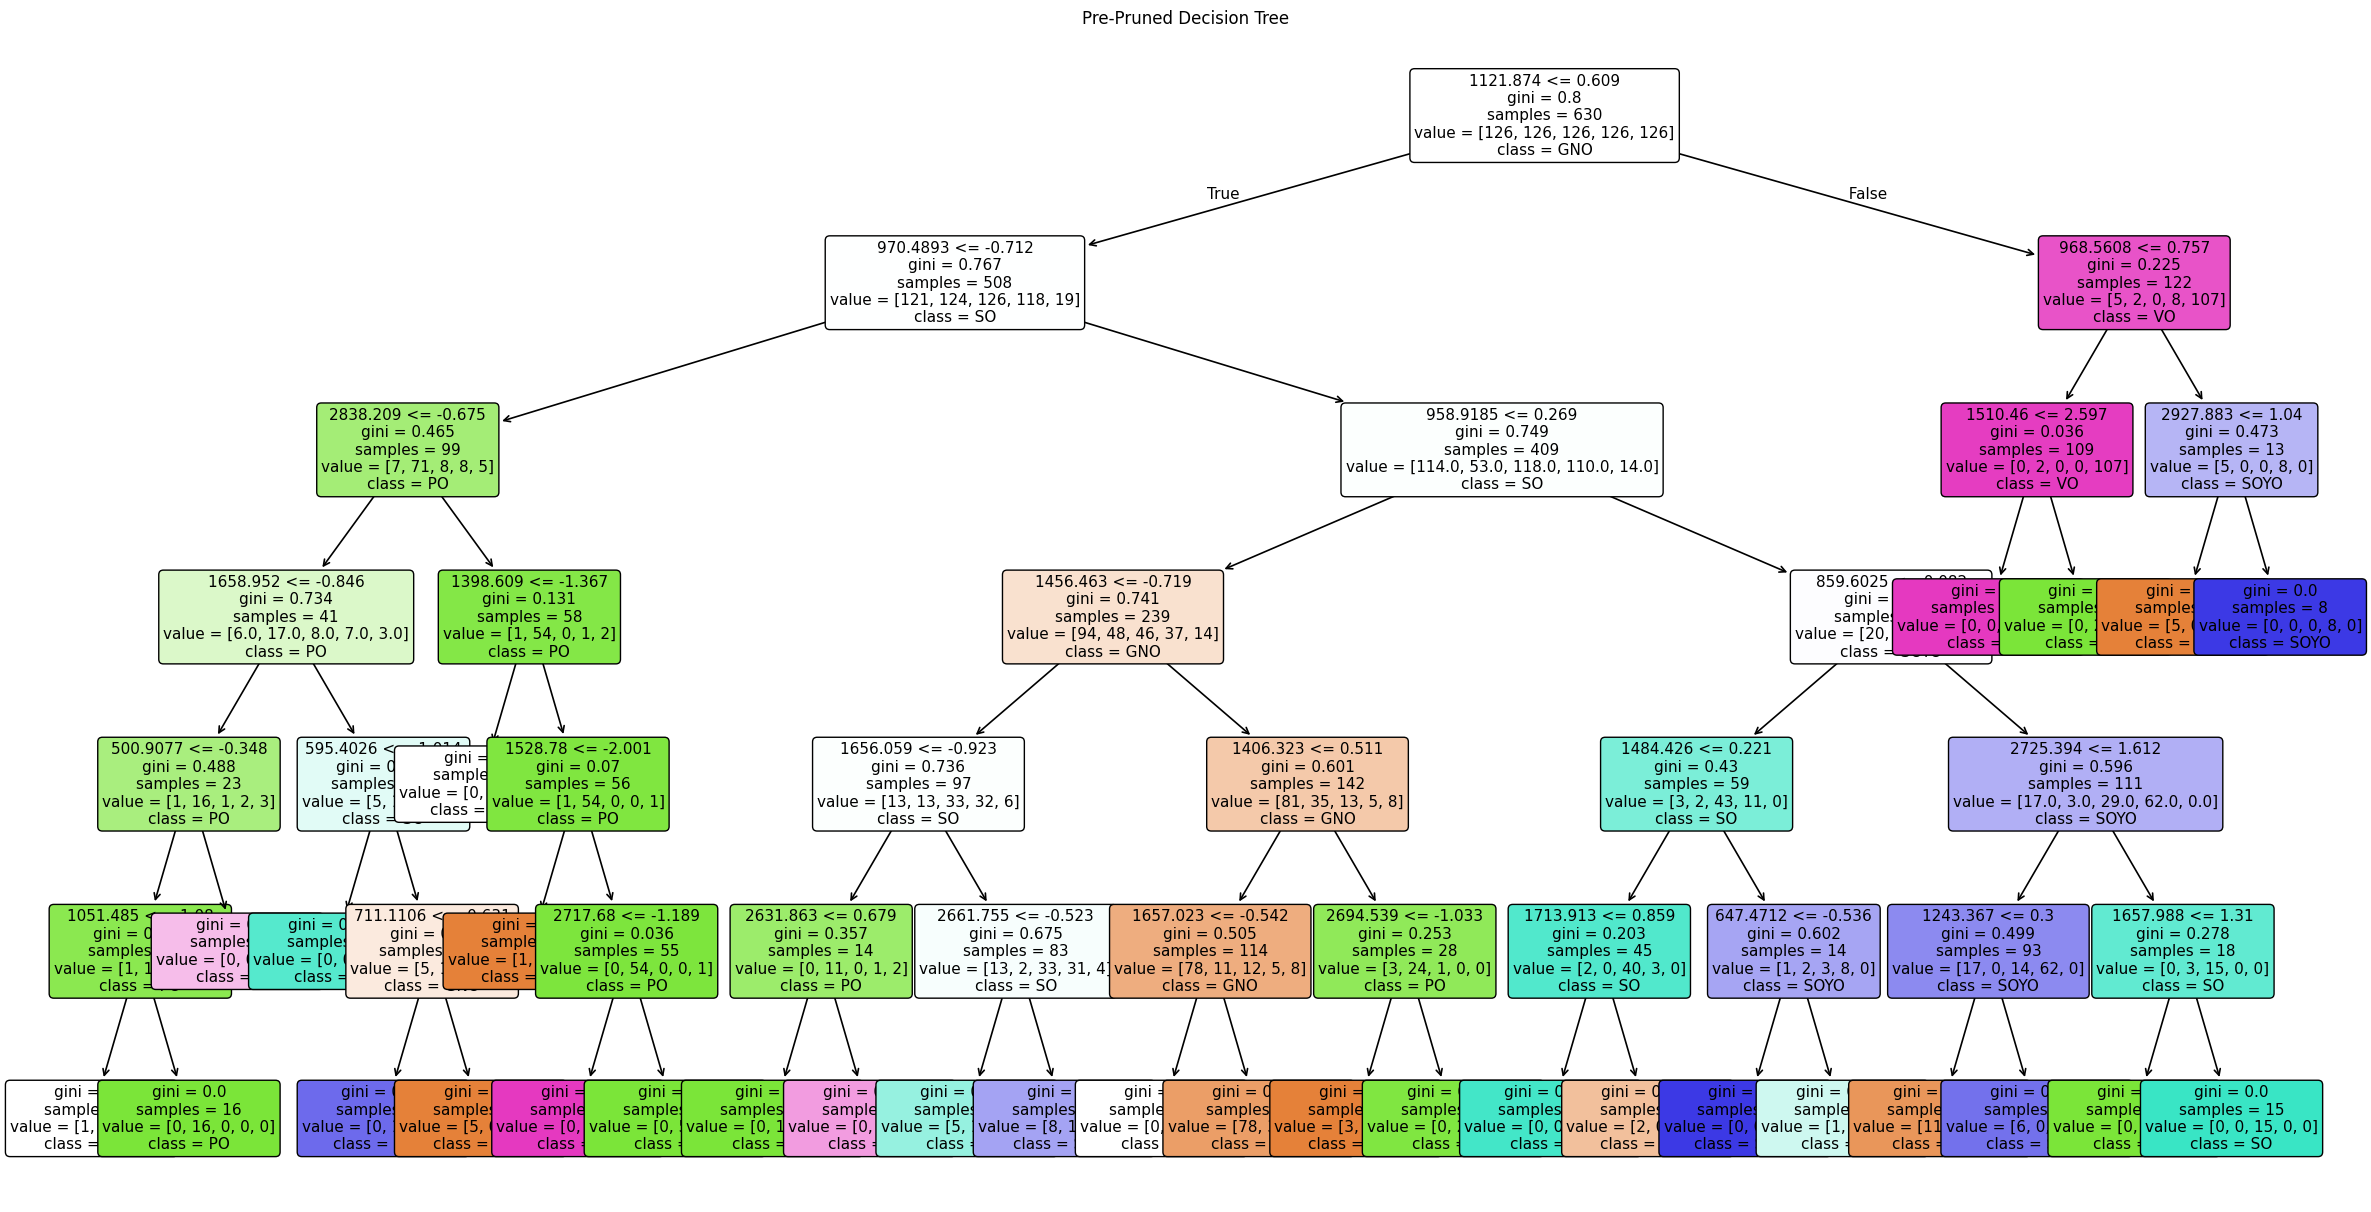

In [28]:
class_names = ['GNO', 'PO', 'SO', 'SOYO', 'VO']

plt.figure(figsize=(24, 12))

out = tree.plot_tree(
    model1,
    feature_names=feature_names,
    class_names=class_names,   # <-- adds class names
    filled=True,
    rounded=True,
    impurity=True,
    proportion=False,          # <-- keeps actual counts
    fontsize=11,
    node_ids=False
)

for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1.2)

plt.tight_layout()

plt.title("Pre-Pruned Decision Tree")
plt.savefig(r"Images\Chips\Prepruned_Decision_Tree_chips.jpg",dpi=600,bbox_inches="tight")
plt.show()

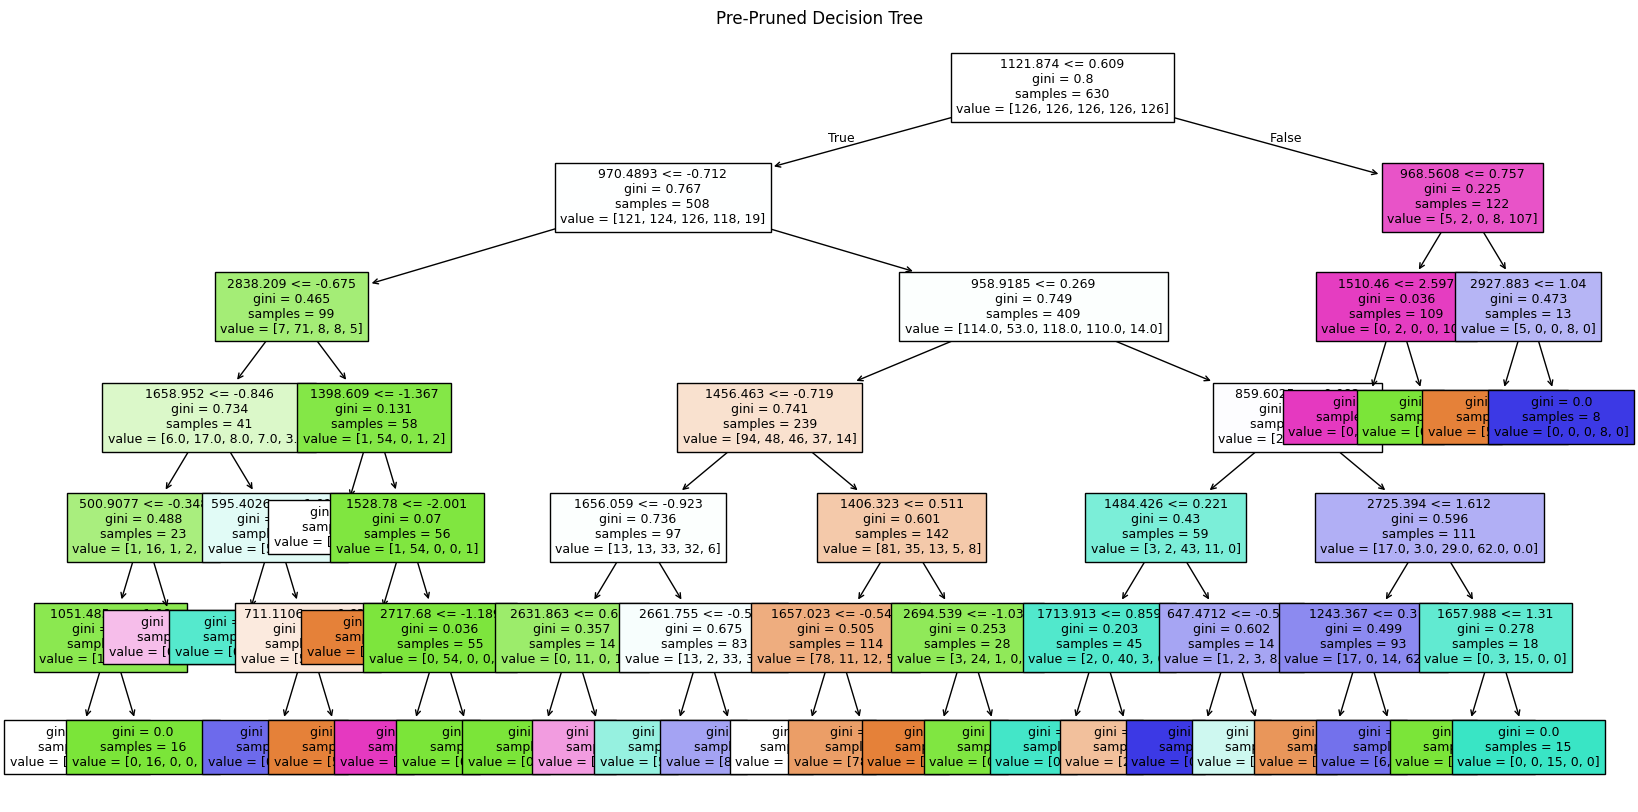

In [29]:
plt.figure(figsize=(20, 10))
out = tree.plot_tree(
    model1,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
# below code will add arrows to the decision tree split if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.title("Pre-Pruned Decision Tree")
plt.show()

In [30]:
for i, name in enumerate(le.classes_):
    print(f"{i}: {name}")

0: GNO C
1: PO C
2: SO C
3: SOYO C
4: VO C


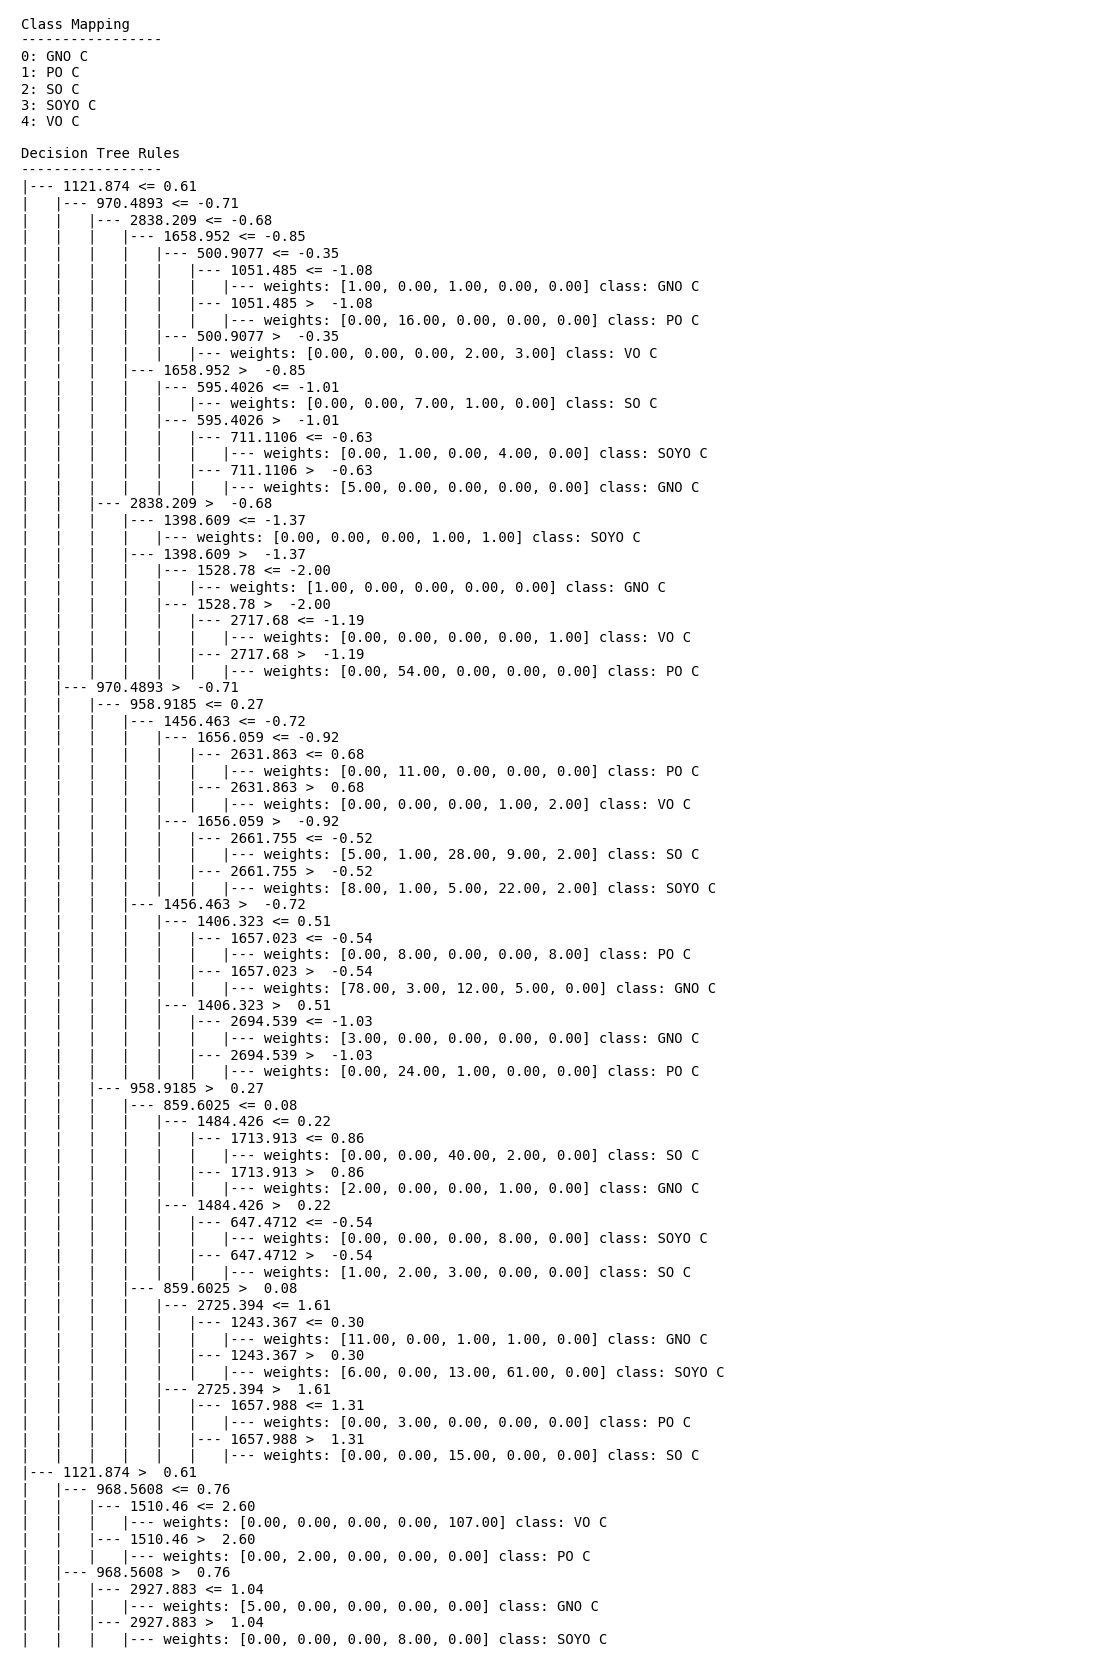

In [31]:
# Create text report
report = tree.export_text(
    model1,
    feature_names=feature_names,
    show_weights=True
)

# Add class mapping at top
mapping_text = "\n".join(
    [f"{i}: {name}" for i, name in enumerate(le.classes_)]
)

full_report = (
    "Class Mapping\n"
    "-----------------\n"
    f"{mapping_text}\n\n"
    "Decision Tree Rules\n"
    "-----------------\n"
    f"{report}"
)

# Create figure
fig, ax = plt.subplots(figsize=(14, 10))
ax.axis("off")

ax.text(
    0.01,
    0.99,
    full_report,
    family="monospace",
    fontsize=10,
    va="top"
)

plt.savefig(r"Images\Chips\Prepruned_Decision_Tree_Text_Report_Chips.jpg",dpi=600,bbox_inches="tight")
plt.show()

In [32]:
# Text report showing the rules of a decision tree -
print(tree.export_text(model1, feature_names=feature_names, show_weights=True))

|--- 1121.874 <= 0.61
|   |--- 970.4893 <= -0.71
|   |   |--- 2838.209 <= -0.68
|   |   |   |--- 1658.952 <= -0.85
|   |   |   |   |--- 500.9077 <= -0.35
|   |   |   |   |   |--- 1051.485 <= -1.08
|   |   |   |   |   |   |--- weights: [1.00, 0.00, 1.00, 0.00, 0.00] class: GNO C
|   |   |   |   |   |--- 1051.485 >  -1.08
|   |   |   |   |   |   |--- weights: [0.00, 16.00, 0.00, 0.00, 0.00] class: PO C
|   |   |   |   |--- 500.9077 >  -0.35
|   |   |   |   |   |--- weights: [0.00, 0.00, 0.00, 2.00, 3.00] class: VO C
|   |   |   |--- 1658.952 >  -0.85
|   |   |   |   |--- 595.4026 <= -1.01
|   |   |   |   |   |--- weights: [0.00, 0.00, 7.00, 1.00, 0.00] class: SO C
|   |   |   |   |--- 595.4026 >  -1.01
|   |   |   |   |   |--- 711.1106 <= -0.63
|   |   |   |   |   |   |--- weights: [0.00, 1.00, 0.00, 4.00, 0.00] class: SOYO C
|   |   |   |   |   |--- 711.1106 >  -0.63
|   |   |   |   |   |   |--- weights: [5.00, 0.00, 0.00, 0.00, 0.00] class: GNO C
|   |   |--- 2838.209 >  -0.68
|   |   

In [33]:
importances = model1.feature_importances_
importances

array([0.01431866, 0.        , 0.        , ..., 0.        , 0.        ,
       0.        ], shape=(1866,))

In [34]:
print(np.sum(importances > 0))

29


**Reading feature importance.** scikit-learn's Gini importance for a wavenumber sums the (sample-weighted) impurity decrease at every split in the tree that used it, then normalizes so all importances sum to 1. It reflects how much a wavenumber helped separate classes *within this specific tree*, not a model-free measure of how discriminative that Raman band is in isolation: because neighboring wavenumbers are highly correlated, the tree only needs to pick one of several near-equivalent candidates at a split, so an unused neighbor can be just as chemically informative as a used one that scores higher here. Only wavenumbers actually used by a split get a nonzero score, which is why the plot below only shows that nonzero subset.

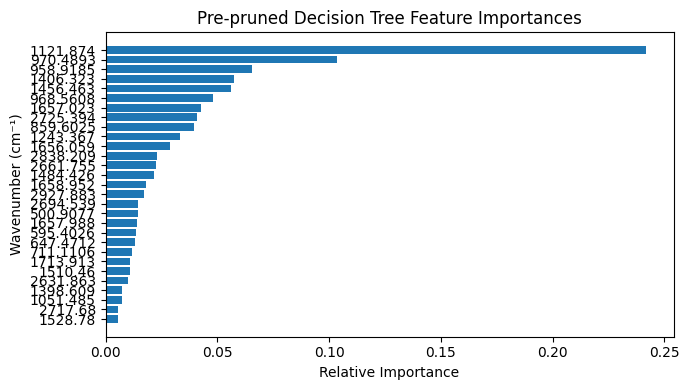

In [35]:
importances = model1.feature_importances_

# Keep only features used by the tree
mask = importances > 0

important_features = np.array(feature_names)[mask]
important_values = importances[mask]

# Sort by importance
idx = np.argsort(important_values)

plt.figure(figsize=(7,4))

plt.barh(
    range(len(idx)),
    important_values[idx]
)

plt.yticks(
    range(len(idx)),
    important_features[idx]
)

plt.xlabel("Relative Importance")
plt.ylabel("Wavenumber (cm⁻¹)")
plt.title("Pre-pruned Decision Tree Feature Importances")

plt.tight_layout()

plt.savefig(r"Images\Chips\decision_tree_feature_importance_Chips.jpg",dpi=600,bbox_inches="tight")
plt.show()

In [36]:
for f, imp in zip(feature_names, importances):
    if imp > 0:
        print(f"{f} : {imp:.4f}")

500.9077 : 0.0143
595.4026 : 0.0136
647.4712 : 0.0132
711.1106 : 0.0117
859.6025 : 0.0394
958.9185 : 0.0656
968.5608 : 0.0481
970.4893 : 0.1036
1051.485 : 0.0074
1121.874 : 0.2420
1243.367 : 0.0333
1398.609 : 0.0076
1406.323 : 0.0577
1456.463 : 0.0564
1484.426 : 0.0217
1510.46 : 0.0109
1528.78 : 0.0054
1656.059 : 0.0287
1657.023 : 0.0429
1657.988 : 0.0139
1658.952 : 0.0179
1713.913 : 0.0112
2631.863 : 0.0102
2661.755 : 0.0226
2694.539 : 0.0143
2717.68 : 0.0055
2725.394 : 0.0407
2838.209 : 0.0231
2927.883 : 0.0171


### Post-pruning

### Post‑pruning via Cost‑Complexity Path: Compute `ccp_alphas` and impurities to study pruning trajectory.

For a fully grown tree *T*, cost-complexity pruning defines

R_α(T) = R(T) + α·|leaves(T)|

where R(T) is T's total training impurity and |leaves(T)| its number of leaves. α trades fit against size: α = 0 is the fully grown tree, and increasing α makes larger subtrees costlier, until at each of a finite sequence of α values the optimal subtree collapses its weakest-link node. `cost_complexity_pruning_path` returns exactly that sequence of α values and each one's corresponding leaf impurity.

In [37]:
clf = DecisionTreeClassifier(random_state=1, class_weight="balanced")
path = clf.cost_complexity_pruning_path(X_train, y_train)
# sklearn's ccp_alphas are already >= 0 in practice; abs() guards against a
# stray floating-point sign flip on a value that should be exactly 0.
ccp_alphas, impurities = abs(path.ccp_alphas), path.impurities

In [38]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.000000,0.000000
1,0.001587,0.001587
2,0.001587,0.003175
3,0.001587,0.004762
4,0.001587,0.006349
...,...,...
68,0.027481,0.500081
69,0.032563,0.565207
70,0.037465,0.602672
71,0.059126,0.661798


### Impurity vs α (training) from the above summary: Heavier pruning (larger α) reduces tree size and increases leaf impurity.


In [39]:
print(model1.get_n_leaves())
print(model1.get_depth())

30
6


In [40]:
alphas = path.ccp_alphas

for alpha in alphas:
    # class_weight="balanced" to match the tree sequence built below and
    # the final selected model - this loop is a depth/leaf diagnostic
    # only (its trees are never kept), but should still describe the
    # same tree the rest of this stage actually uses.
    clf = DecisionTreeClassifier(random_state=1, ccp_alpha=alpha, class_weight="balanced")
    clf.fit(X_train, y_train)

    print(
        f"alpha={alpha:.6f}",
        "depth=", clf.get_depth(),
        "leaves=", clf.get_n_leaves()
    )

alpha=0.000000 depth= 11 leaves= 79


alpha=0.001587 depth= 11 leaves= 70


alpha=0.001587 depth= 11 leaves= 70


alpha=0.001587 depth= 11 leaves= 70


alpha=0.001587 depth= 11 leaves= 70


alpha=0.001587 depth= 11 leaves= 70


alpha=0.001587 depth= 11 leaves= 70


alpha=0.001587 depth= 11 leaves= 70


alpha=0.001587 depth= 11 leaves= 70


alpha=0.002116 depth= 10 leaves= 66


alpha=0.002116 depth= 10 leaves= 66


alpha=0.002116 depth= 10 leaves= 66


alpha=0.002116 depth= 10 leaves= 66


alpha=0.002381 depth= 10 leaves= 64


alpha=0.002381 depth= 10 leaves= 64


alpha=0.002381 depth= 10 leaves= 63


alpha=0.002540 depth= 10 leaves= 62


alpha=0.002778 depth= 10 leaves= 60


alpha=0.002778 depth= 10 leaves= 60


alpha=0.002822 depth= 10 leaves= 59


alpha=0.002910 depth= 10 leaves= 58


alpha=0.002988 depth= 10 leaves= 57


alpha=0.003048 depth= 10 leaves= 56


alpha=0.003090 depth= 10 leaves= 54


alpha=0.003628 depth= 10 leaves= 53


alpha=0.003704 depth= 10 leaves= 52


alpha=0.003741 depth= 10 leaves= 51


alpha=0.003810 depth= 10 leaves= 49


alpha=0.003810 depth= 10 leaves= 49


alpha=0.004029 depth= 10 leaves= 48


alpha=0.004233 depth= 10 leaves= 47


alpha=0.004233 depth= 10 leaves= 46


alpha=0.004330 depth= 10 leaves= 45


alpha=0.004348 depth= 10 leaves= 44


alpha=0.004635 depth= 9 leaves= 43


alpha=0.004762 depth= 9 leaves= 42


alpha=0.005291 depth= 9 leaves= 41


alpha=0.005820 depth= 9 leaves= 40


alpha=0.006047 depth= 9 leaves= 39


alpha=0.006061 depth= 9 leaves= 38


alpha=0.006233 depth= 9 leaves= 37


alpha=0.006369 depth= 9 leaves= 36


alpha=0.006547 depth= 9 leaves= 35


alpha=0.006667 depth= 9 leaves= 34


alpha=0.006698 depth= 9 leaves= 33


alpha=0.006716 depth= 9 leaves= 32


alpha=0.007141 depth= 9 leaves= 31


alpha=0.007559 depth= 9 leaves= 30


alpha=0.007692 depth= 9 leaves= 29


alpha=0.007769 depth= 9 leaves= 28


alpha=0.007937 depth= 9 leaves= 27


alpha=0.007991 depth= 8 leaves= 26


alpha=0.008176 depth= 8 leaves= 25


alpha=0.008177 depth= 8 leaves= 24


alpha=0.009768 depth= 8 leaves= 23


alpha=0.009877 depth= 8 leaves= 22


alpha=0.010179 depth= 8 leaves= 21


alpha=0.010204 depth= 7 leaves= 19


alpha=0.010215 depth= 7 leaves= 18


alpha=0.011463 depth= 7 leaves= 17


alpha=0.012390 depth= 7 leaves= 16


alpha=0.012507 depth= 7 leaves= 15


alpha=0.013210 depth= 7 leaves= 14


alpha=0.013418 depth= 6 leaves= 12


alpha=0.016408 depth= 6 leaves= 11


alpha=0.019029 depth= 6 leaves= 10


alpha=0.022871 depth= 6 leaves= 8


alpha=0.024483 depth= 5 leaves= 7


alpha=0.027481 depth= 5 leaves= 6


alpha=0.032563 depth= 3 leaves= 4


alpha=0.037465 depth= 2 leaves= 3


alpha=0.059126 depth= 1 leaves= 2


alpha=0.138202 depth= 0 leaves= 1


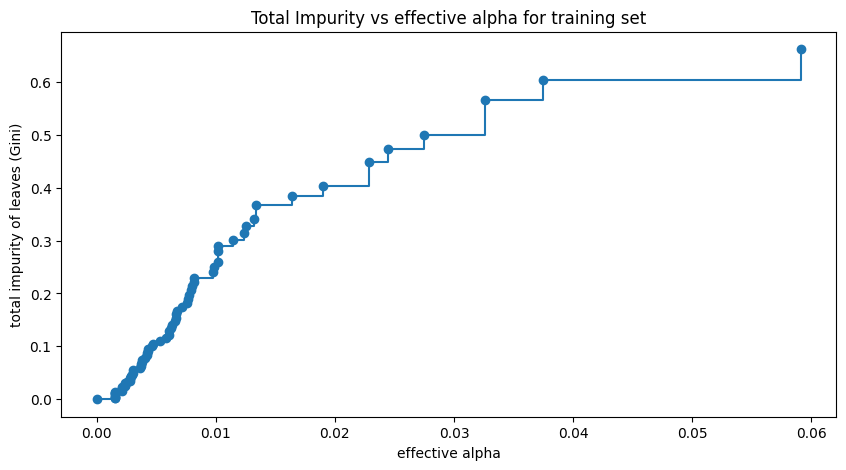

In [41]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves (Gini)")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

### Fit trees across α values: Train a sequence of pruned trees; we’ll compare metrics across α.


In [42]:
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=1, ccp_alpha=ccp_alpha, class_weight="balanced")
    clf.fit(X_train, y_train)
    clfs.append(clf)
print("Number of nodes in the last tree is: {} with ccp_alpha: {}".format(clfs[-1].tree_.node_count, ccp_alphas[-1]))

Number of nodes in the last tree is: 1 with ccp_alpha: 0.13820188460049043


In [43]:
param_grid = {"ccp_alpha": list(ccp_alphas)}
search = GridSearchCV(DecisionTreeClassifier(random_state=1, class_weight='balanced'),param_grid=param_grid,
scoring="recall_weighted",cv=StratifiedKFold(n_splits= 5, shuffle=True, random_state=1),refit=True,
verbose= 1)
search.fit(X_train, y_train)

cv_table = pd.DataFrame({
"ccp_alpha": param_grid["ccp_alpha"],
"mean_cv_recall": search.cv_results_["mean_test_score"],
"std_cv_recall": search.cv_results_["std_test_score"],
}).sort_values("ccp_alpha").reset_index(drop=True)

Fitting 5 folds for each of 73 candidates, totalling 365 fits


In [44]:
model2 = search.best_estimator_
cv_table.head()

,ccp_alpha,mean_cv_recall,std_cv_recall
0,0.000000,0.596825,0.055077
1,0.001587,0.596825,0.055077
2,0.001587,0.596825,0.055077
3,0.001587,0.596825,0.055077
4,0.001587,0.596825,0.055077


In [45]:
# ============================================================
# Hyperparameters used for the Post-Pruned Decision Tree
# ============================================================

print("=" * 70)
print("POST-PRUNED DECISION TREE: ALL HYPERPARAMETERS")
print("=" * 70)

postpruned_params = model2.get_params(deep=True)

for param, value in postpruned_params.items():
    print(f"{param}: {value}")

print("=" * 70)
print("BEST POST-PRUNING PARAMETER SELECTED BY GRID SEARCH")
print("=" * 70)

for param, value in search.best_params_.items():
    print(f"{param}: {value}")

print("=" * 70)
print("BEST CROSS-VALIDATION SCORE")
print("=" * 70)

print(f"Best weighted recall: {search.best_score_:.6f}")

print("=" * 70)
print("Tree characteristics after fitting")
print("=" * 70)

print(f"Tree depth       : {model2.get_depth()}")
print(f"Number of leaves : {model2.get_n_leaves()}")
print(f"Number of nodes  : {model2.tree_.node_count}")

POST-PRUNED DECISION TREE: ALL HYPERPARAMETERS
ccp_alpha: 0.011462996879663543
class_weight: balanced
criterion: gini
max_depth: None
max_features: None
max_leaf_nodes: None
min_impurity_decrease: 0.0
min_samples_leaf: 1
min_samples_split: 2
min_weight_fraction_leaf: 0.0
monotonic_cst: None
random_state: 1
splitter: best
BEST POST-PRUNING PARAMETER SELECTED BY GRID SEARCH
ccp_alpha: 0.011462996879663543
BEST CROSS-VALIDATION SCORE
Best weighted recall: 0.625397
Tree characteristics after fitting
Tree depth       : 7
Number of leaves : 17
Number of nodes  : 33


### Node count / Depth vs α: Sanity‑check that pruning controls complexity as expected.

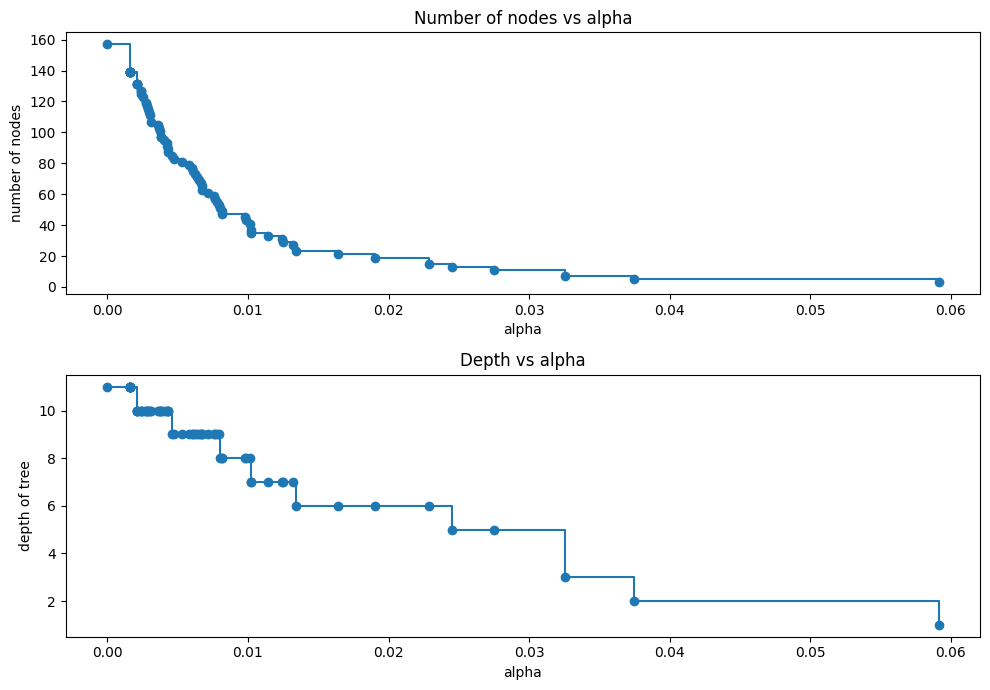

In [46]:
# Drop the last alpha: it always collapses the tree to a single root node
# (uninformative) - see the last line printed in the loop above (leaves=1).
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1, figsize=(10, 7))
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

In [47]:
recall_train = []
for clf in clfs:
    pred_train = clf.predict(X_train)
    values_train = recall_score(y_train, pred_train, average='weighted')
    recall_train.append(values_train)

In [48]:
recall_test = []
for clf in clfs:
    pred_test = clf.predict(X_test)
    values_test = recall_score(y_test, pred_test, average='weighted')
    recall_test.append(values_test)

In [49]:
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

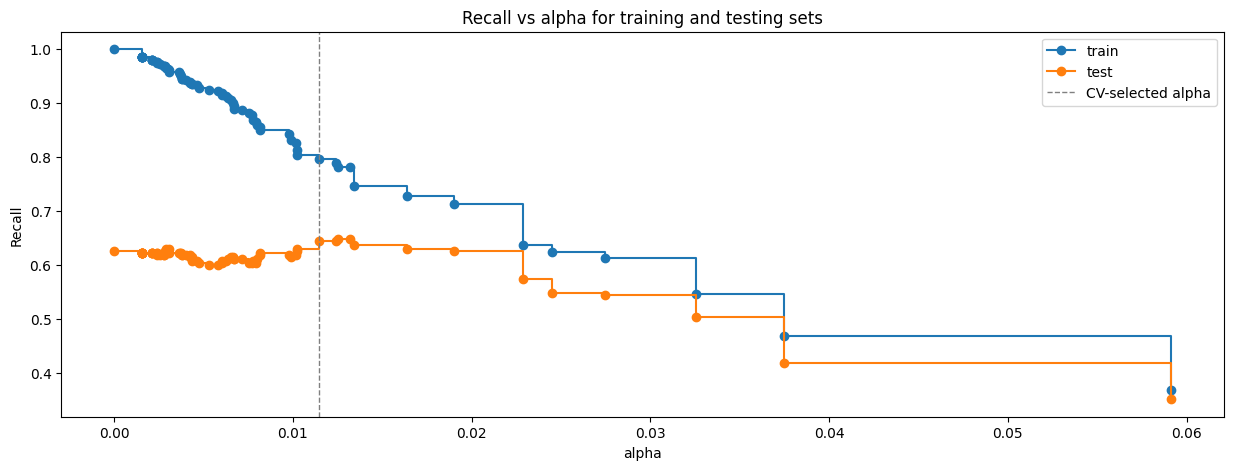

In [50]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("Recall")
ax.set_title("Recall vs alpha for training and testing sets")
ax.plot(
    ccp_alphas, recall_train, marker="o", label="train", drawstyle="steps-post",
)
ax.plot(ccp_alphas, recall_test, marker="o", label="test", drawstyle="steps-post")
ax.axvline(model2.ccp_alpha, color="gray", linestyle="--", linewidth=1, label="CV-selected alpha")
ax.legend()
plt.show()

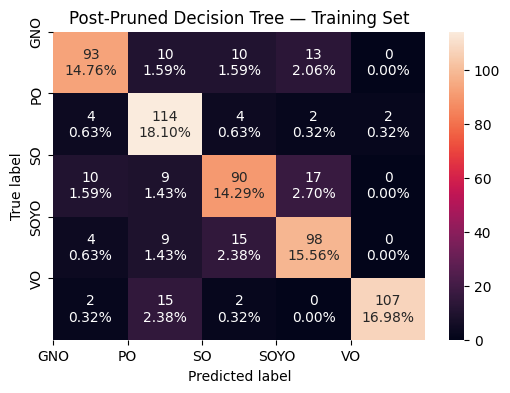

In [51]:
model3 = model2
confusion_matrix_sklearn(model3, X_train, y_train)
ax = plt.gca()
labels = ['GNO', 'PO', 'SO', 'SOYO', 'VO']
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_title("Post-Pruned Decision Tree — Training Set")
plt.savefig(r"Images\Chips\confusion_matrix_train_postpruned_Chips.jpg",dpi=300,bbox_inches="tight")
plt.show()

In [52]:
decision_tree_post_perf_train = model_performance_classification_sklearn(
    model3, X_train, y_train
)
decision_tree_post_perf_train

,Accuracy,Recall,Precision,F1
0,0.796825,0.796825,0.805685,0.797781


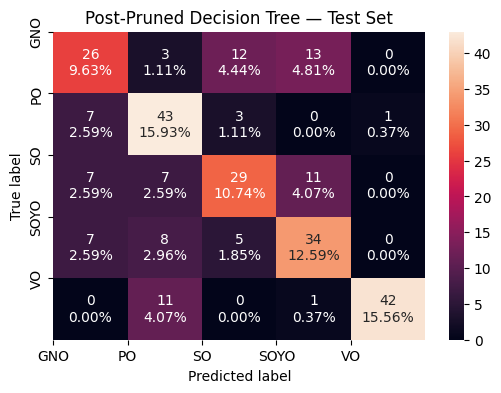

In [53]:
model3 = model2
confusion_matrix_sklearn(model3, X_test, y_test)
ax = plt.gca()
labels = ['GNO', 'PO', 'SO', 'SOYO', 'VO']
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_title("Post-Pruned Decision Tree — Test Set")
plt.savefig(r"Images\Chips\confusion_matrix_test_postpruned_chips.jpg",dpi=300,bbox_inches="tight")
plt.show()

In [54]:
decision_tree_post_test = model_performance_classification_sklearn(
    model3, X_test, y_test
)
decision_tree_post_test

,Accuracy,Recall,Precision,F1
0,0.644444,0.644444,0.659053,0.645649


### decision tree for post-pruning

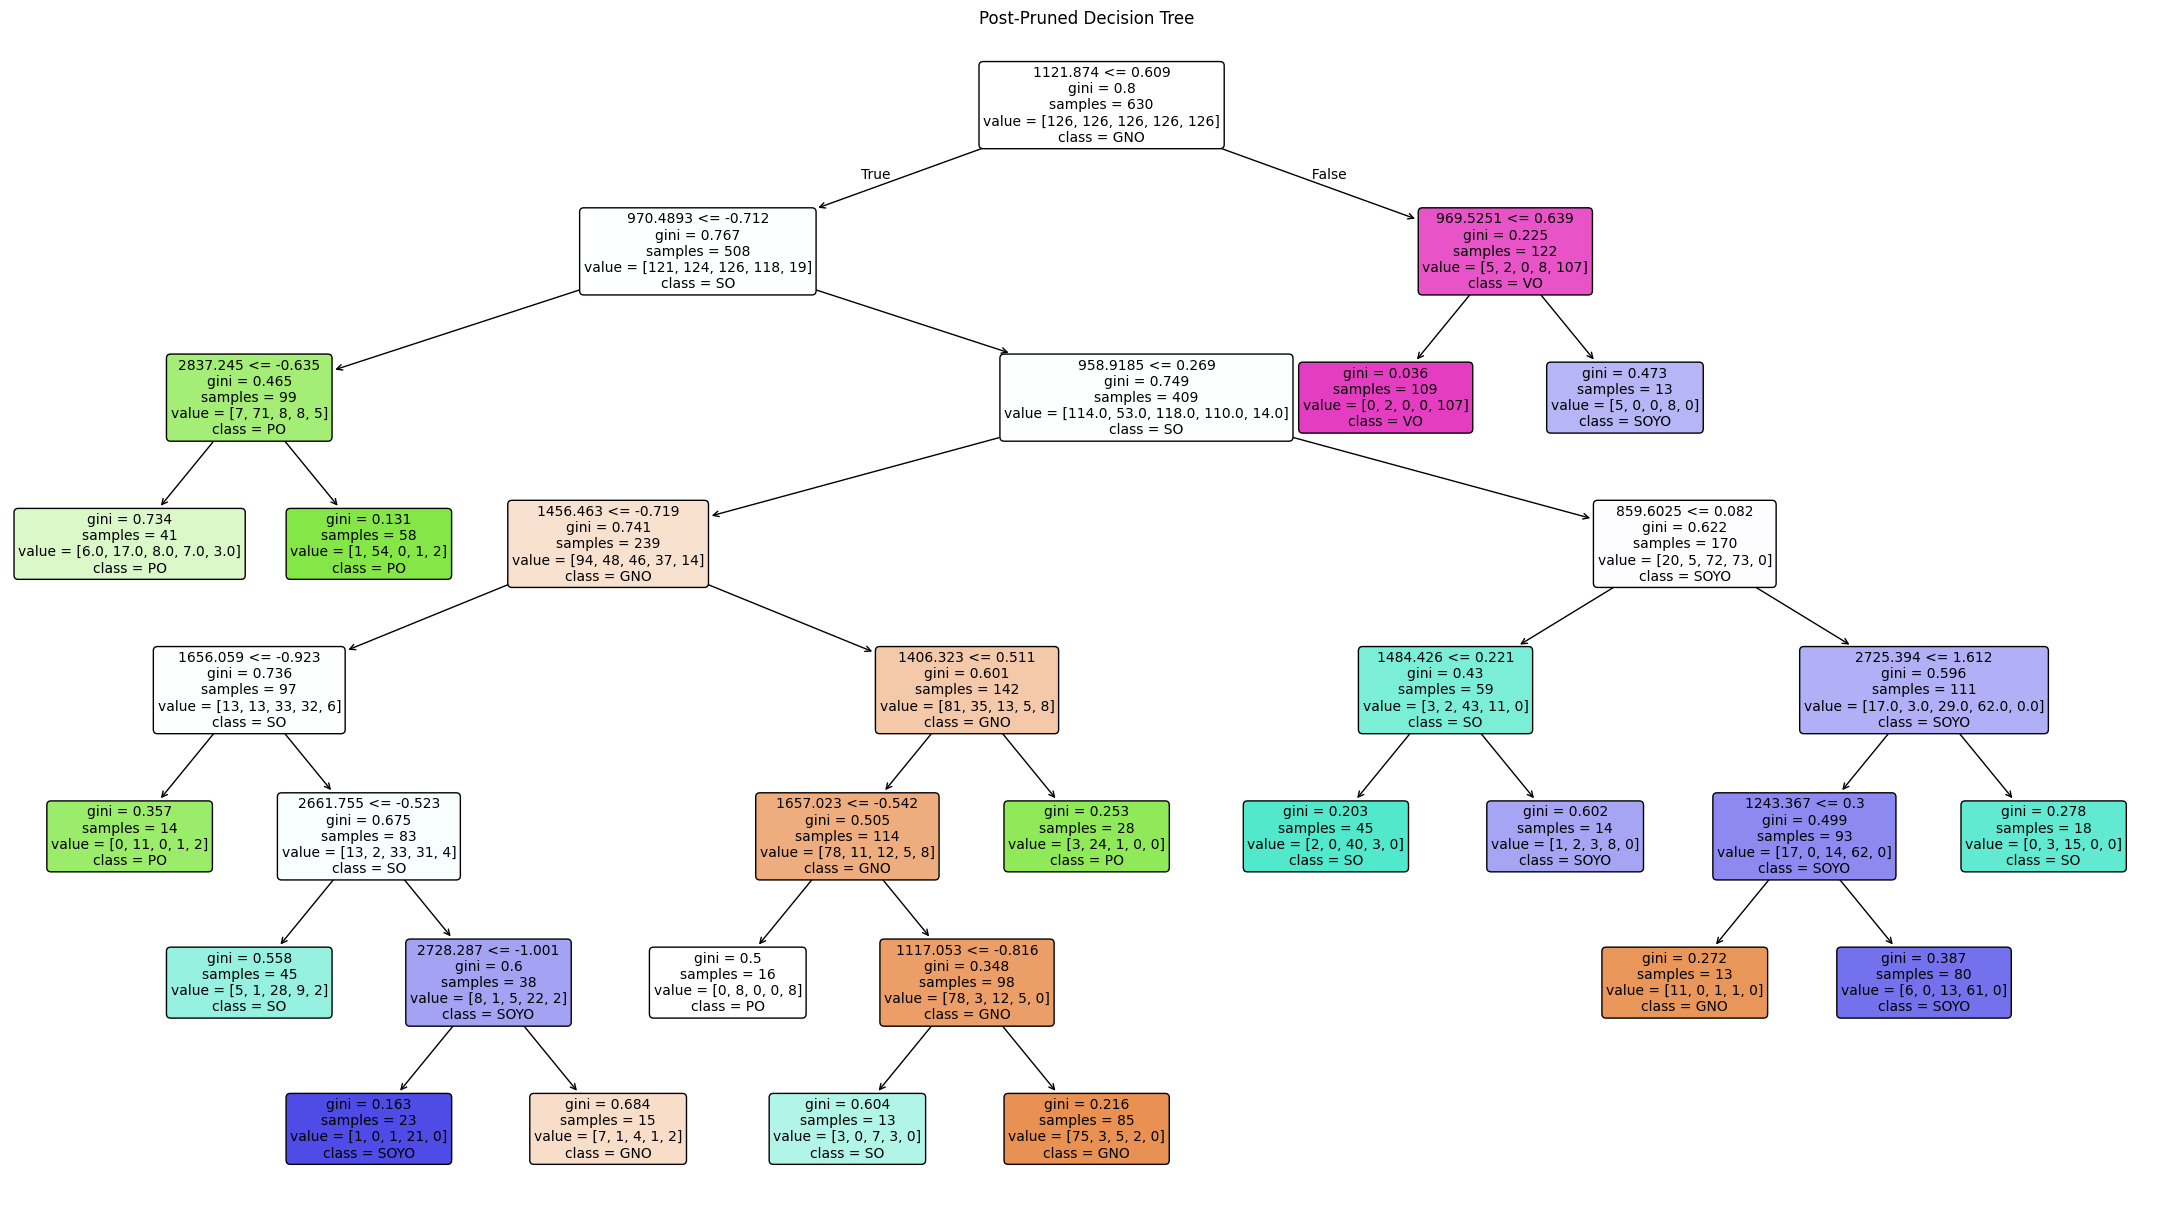

In [55]:
class_names = ['GNO', 'PO', 'SO', 'SOYO', 'VO']
plt.figure(figsize=(22, 12))

out = tree.plot_tree(
    model3,
    feature_names=feature_names,
    class_names=class_names,   # <-- add class labels
    filled=True,
    rounded=True,
    fontsize=10,
    node_ids=False,
    proportion=False,          # keep sample counts
    impurity=True              # keep gini values
)

# Make arrows darker
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)

plt.tight_layout()

plt.title("Post-Pruned Decision Tree")
plt.savefig(r"Images\Chips\postpruned_decision_tree_Chips.jpg",dpi=600,bbox_inches="tight")
plt.show()

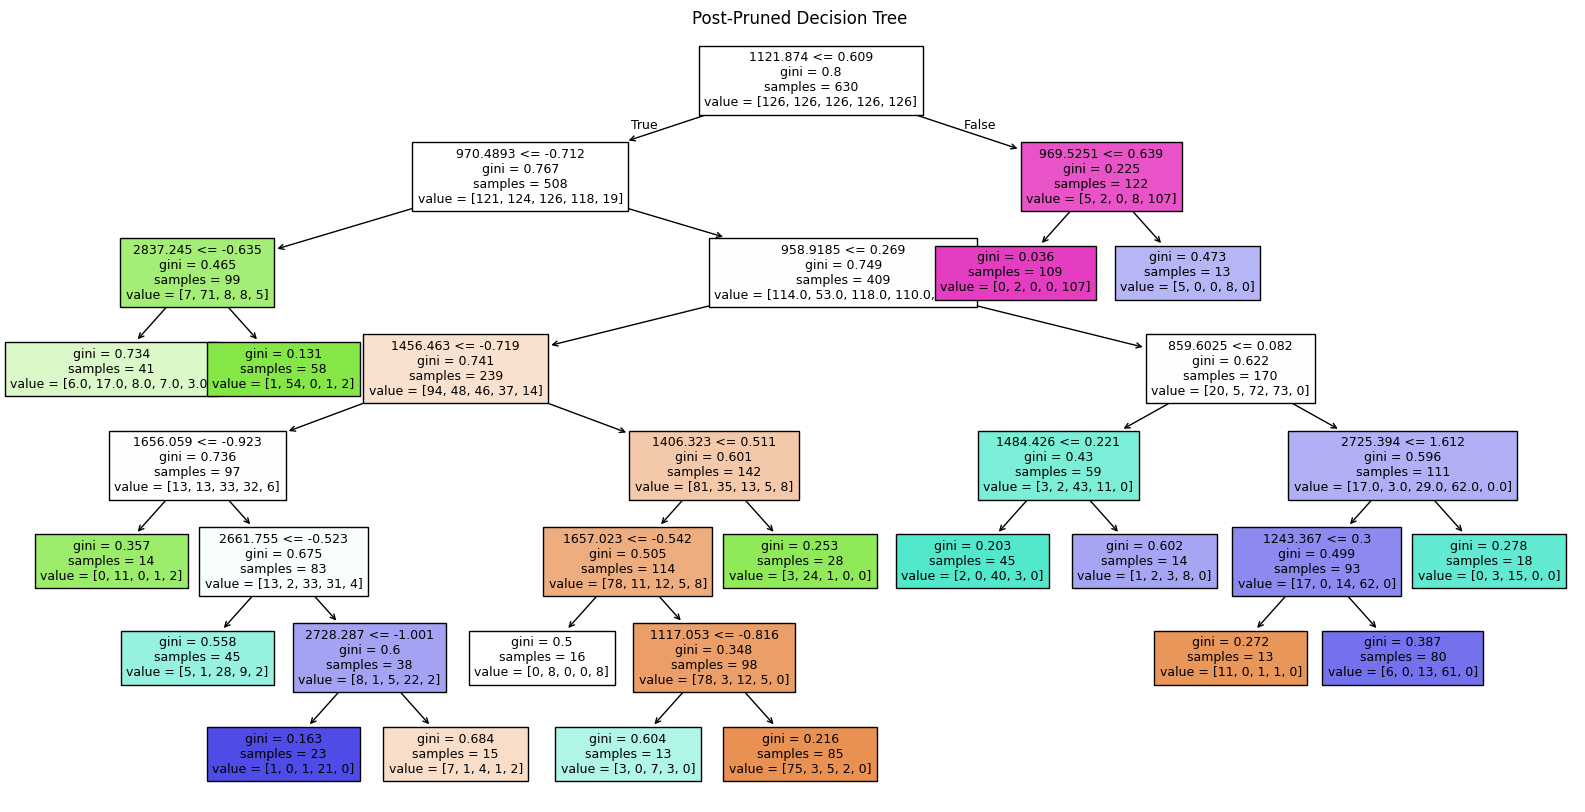

In [56]:
plt.figure(figsize=(20, 10))

out = tree.plot_tree(
    model3,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.title("Post-Pruned Decision Tree")
plt.show()

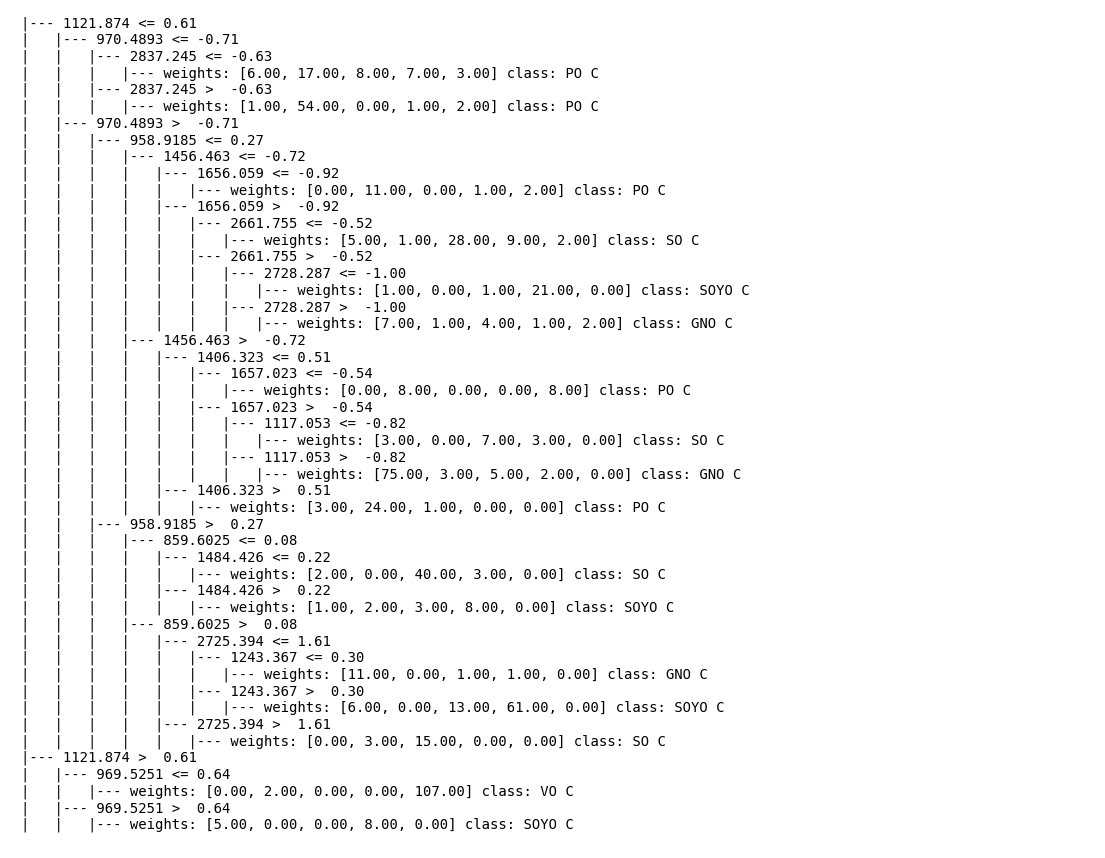

In [57]:
report = tree.export_text(
    model3,
    feature_names=feature_names,
    show_weights=True
)

fig, ax = plt.subplots(figsize=(14, 8))
ax.axis("off")

ax.text(
    0.01,
    0.99,
    report,
    transform=ax.transAxes,
    fontsize=10,
    family="monospace",
    va="top"
)

plt.savefig(r"Images\Chips\postpruned_tree_rules_Chips.jpg",dpi=600,bbox_inches="tight")
plt.show()

In [58]:
# Text report showing the rules of a decision tree -
print(tree.export_text(model3, feature_names=feature_names, show_weights=True))

|--- 1121.874 <= 0.61
|   |--- 970.4893 <= -0.71
|   |   |--- 2837.245 <= -0.63
|   |   |   |--- weights: [6.00, 17.00, 8.00, 7.00, 3.00] class: PO C
|   |   |--- 2837.245 >  -0.63
|   |   |   |--- weights: [1.00, 54.00, 0.00, 1.00, 2.00] class: PO C
|   |--- 970.4893 >  -0.71
|   |   |--- 958.9185 <= 0.27
|   |   |   |--- 1456.463 <= -0.72
|   |   |   |   |--- 1656.059 <= -0.92
|   |   |   |   |   |--- weights: [0.00, 11.00, 0.00, 1.00, 2.00] class: PO C
|   |   |   |   |--- 1656.059 >  -0.92
|   |   |   |   |   |--- 2661.755 <= -0.52
|   |   |   |   |   |   |--- weights: [5.00, 1.00, 28.00, 9.00, 2.00] class: SO C
|   |   |   |   |   |--- 2661.755 >  -0.52
|   |   |   |   |   |   |--- 2728.287 <= -1.00
|   |   |   |   |   |   |   |--- weights: [1.00, 0.00, 1.00, 21.00, 0.00] class: SOYO C
|   |   |   |   |   |   |--- 2728.287 >  -1.00
|   |   |   |   |   |   |   |--- weights: [7.00, 1.00, 4.00, 1.00, 2.00] class: GNO C
|   |   |   |--- 1456.463 >  -0.72
|   |   |   |   |--- 1406.323 

In [59]:
importances = model3.feature_importances_
indices = np.argsort(importances)

In [60]:
np.sum(importances > 0)

np.int64(16)

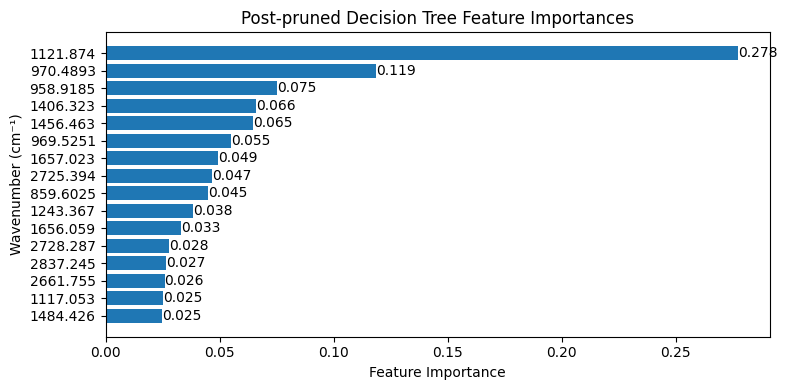

In [61]:
importances = model3.feature_importances_

# Keep only important features
mask = importances > 0

important_features = np.array(feature_names)[mask]
important_importances = importances[mask]

# Sort
idx = np.argsort(important_importances)

plt.figure(figsize=(8,4))

plt.barh(
    important_features[idx],
    important_importances[idx]
)

plt.xlabel("Feature Importance")
plt.ylabel("Wavenumber (cm⁻¹)")
plt.title("Post-pruned Decision Tree Feature Importances")

# Print values on bars
for i, v in enumerate(important_importances[idx]):
    plt.text(v, i, f"{v:.3f}", va="center")

plt.tight_layout()
plt.savefig(r"Images\Chips\PostPruned_Feature_Importance_Chips.jpg",dpi=600,bbox_inches="tight")
plt.show()

In [62]:
imp_df = pd.DataFrame({
    "Wavenumber": np.array(feature_names)[mask],
    "Importance": importances[mask]
})

imp_df = imp_df.sort_values(
    "Importance",
    ascending=False
)

print(imp_df)

   Wavenumber  Importance
5    1121.874    0.277511
3    970.4893    0.118726
1    958.9185    0.075231
7    1406.323    0.066151
8    1456.463    0.064621
2    969.5251    0.055182
11   1657.023    0.049162
13   2725.394    0.046715
0    859.6025    0.045135
6    1243.367    0.038210
10   1656.059    0.032947
14   2728.287    0.027996
15   2837.245    0.026525
12   2661.755    0.025892
4    1117.053    0.025114
9    1484.426    0.024879


### Comparision

In [63]:
# training performance comparison
models_train_comp_df = pd.concat(
    [
        decision_tree_default_perf_train.T,
        decision_tree_tune_perf_train.T,
        decision_tree_post_perf_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree (sklearn default),Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,1.0,0.847619,0.796825
Recall,1.0,0.847619,0.796825
Precision,1.0,0.851594,0.805685
F1,1.0,0.848487,0.797781


In [64]:
# testing performance comparison
models_test_comp_df = pd.concat(
    [
        decision_tree_default_perf_test.T,
        decision_tree_tune_perf_test.T,
        decision_tree_post_test.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Test set performance comparison:")
models_test_comp_df

Test set performance comparison:


,Decision Tree (sklearn default),Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.625926,0.648148,0.644444
Recall,0.625926,0.648148,0.644444
Precision,0.629598,0.653806,0.659053
F1,0.626763,0.649332,0.645649


In [65]:
hyperparameter_comparison = pd.DataFrame({
    "Default Tree": model0.get_params(deep=True),
    "Pre-Pruned Tree": model1.get_params(deep=True),
    "Post-Pruned Tree": model2.get_params(deep=True)
})

print(hyperparameter_comparison)

                         Default Tree Pre-Pruned Tree Post-Pruned Tree
ccp_alpha                         0.0             0.0         0.011463
class_weight                 balanced        balanced         balanced
criterion                        gini            gini             gini
max_depth                        None               6             None
max_features                     None            None             None
max_leaf_nodes                   None              50             None
min_impurity_decrease             0.0             0.0              0.0
min_samples_leaf                    1               1                1
min_samples_split                   2              10                2
min_weight_fraction_leaf          0.0             0.0              0.0
monotonic_cst                    None            None             None
random_state                        1               1                1
splitter                         best            best             best


### Since features importance plots in cells 30 and 48 are complex (because of 3,000 + features), let us select top-20 and plot the same data

In [66]:
def plot_topk_importances(estimator, feature_names, top_k=20, title="Top feature importances"):
    importances = getattr(estimator, 'feature_importances_', None)
    if importances is None:
        raise ValueError("Estimator has no attribute 'feature_importances_'.")

    imp = pd.Series(importances, index=feature_names)
    imp_nz = imp[imp > 0].sort_values(ascending=False)
    if imp_nz.empty:
        print('All importances are zero (common for some pruned trees).')
        return

    top = imp_nz.head(top_k).sort_values()   # ascending for barh
    plt.figure(figsize=(8, max(3, 0.4*len(top))))
    plt.title(f"{title} (top {len(top)})")
    plt.barh(top.index, top.values, color='mediumpurple')
    plt.xlabel('Gini importance (relative)')
    plt.ylabel('Wavenumber (cm⁻¹)')
    plt.tight_layout()
    plt.show()

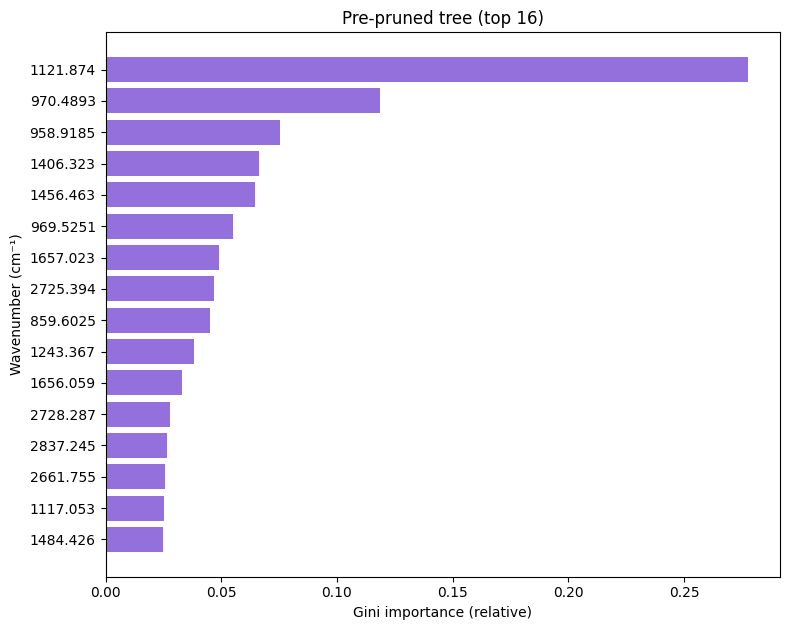

In [67]:
plot_topk_importances(model2, feature_names, top_k=25, title='Pre‑pruned tree')

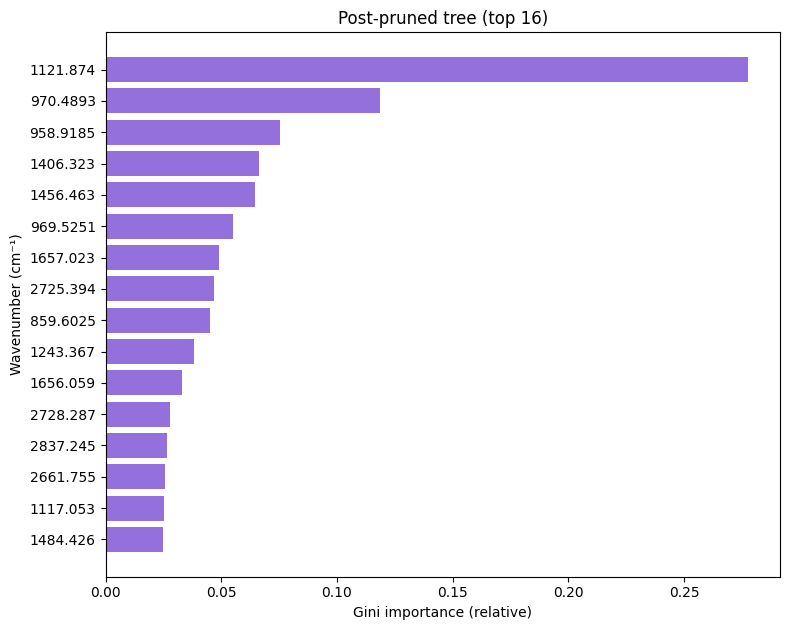

In [68]:
plot_topk_importances(model3, feature_names, top_k=25, title='Post‑pruned tree')